# Практическое занятие №2: Настройка и улучшение ML-модели

**Задача:** Улучшить модель классификации оттока клиентов с помощью SMOTE и GridSearchCV.  
**Датасет:** `telecom_churn.csv`  
**Методы:** SMOTE, GridSearchCV, ROC-кривая, Feature Importance

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')

## Загрузка и подготовка данных

In [42]:
df = pd.read_csv('telecom_churn.csv')

X = df.drop('churn', axis=1)
y = df['churn'].astype(int)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features)
    ])

## 1. Диагностика проблемы старой модели

In [43]:
old_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

old_model.fit(X_train, y_train)
y_pred_old = old_model.predict(X_test)

print("Отчет о классификации (Старая модель):")
print(classification_report(y_test, y_pred_old, target_names=['Лояльные (0)', 'Ушедшие (1)']))

old_acc = accuracy_score(y_test, y_pred_old)
old_prec = precision_score(y_test, y_pred_old)
old_rec = recall_score(y_test, y_pred_old)
old_f1 = f1_score(y_test, y_pred_old)

Отчет о классификации (Старая модель):
              precision    recall  f1-score   support

Лояльные (0)       0.96      0.98      0.97       709
 Ушедшие (1)       0.90      0.76      0.82       125

    accuracy                           0.95       834
   macro avg       0.93      0.87      0.90       834
weighted avg       0.95      0.95      0.95       834



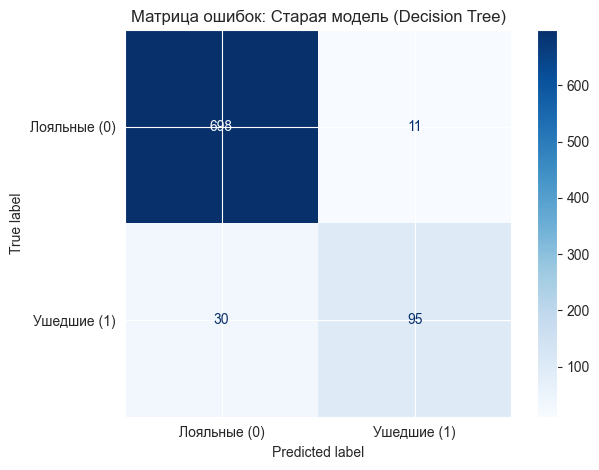


Анализ классов:
В выборке присутствует сильный дисбаланс: лояльных клиентов подавляющее большинство. Ошибки False Negative (когда мы не предсказали уход клиента, а он ушел) обходятся бизнесу намного дороже, так как мы теряем доход. Наша цель – повысить показатель Recall для ушедших клиентов (класс 1).


In [44]:
cm_old = confusion_matrix(y_test, y_pred_old)
disp_old = ConfusionMatrixDisplay(confusion_matrix=cm_old, display_labels=['Лояльные (0)', 'Ушедшие (1)'])
disp_old.plot(cmap='Blues', values_format='d')
plt.title("Матрица ошибок: Старая модель (Decision Tree)")
plt.tight_layout()
plt.savefig('confusion_matrix_old.png')
plt.show()

print("\nАнализ классов:\nВ выборке присутствует сильный дисбаланс: лояльных клиентов подавляющее большинство. "
      "Ошибки False Negative (когда мы не предсказали уход клиента, а он ушел) обходятся бизнесу намного дороже, "
      "так как мы теряем доход. Наша цель – повысить показатель Recall для ушедших клиентов (класс 1).")

## 2. Системный поиск лучших параметров (GridSearchCV + SMOTE)

In [45]:
new_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    new_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Начат поиск оптимальных параметров по сетке с 5-Fold кросс-валидацией...")
grid_search.fit(X_train, y_train)

print("\nЛучшая комбинация гиперпараметров (best_params_):")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"Лучший результат кросс-валидации (F1 best_score_): {grid_search.best_score_:.4f}")

Начат поиск оптимальных параметров по сетке с 5-Fold кросс-валидацией...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Лучшая комбинация гиперпараметров (best_params_):
  classifier__criterion: entropy
  classifier__max_depth: 10
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 10
Лучший результат кросс-валидации (F1 best_score_): 0.7845


## 3. Финальная оценка улучшенной модели

In [46]:
best_model = grid_search.best_estimator_

y_pred_new = best_model.predict(X_test)
y_prob_new = best_model.predict_proba(X_test)[:, 1]

new_acc = accuracy_score(y_test, y_pred_new)
new_prec = precision_score(y_test, y_pred_new)
new_rec = recall_score(y_test, y_pred_new)
new_f1 = f1_score(y_test, y_pred_new)

print("Отчет о классификации (Новая модель):")
print(classification_report(y_test, y_pred_new, target_names=['Лояльные (0)', 'Ушедшие (1)']))

Отчет о классификации (Новая модель):
              precision    recall  f1-score   support

Лояльные (0)       0.95      0.98      0.96       709
 Ушедшие (1)       0.84      0.72      0.78       125

    accuracy                           0.94       834
   macro avg       0.90      0.85      0.87       834
weighted avg       0.94      0.94      0.94       834



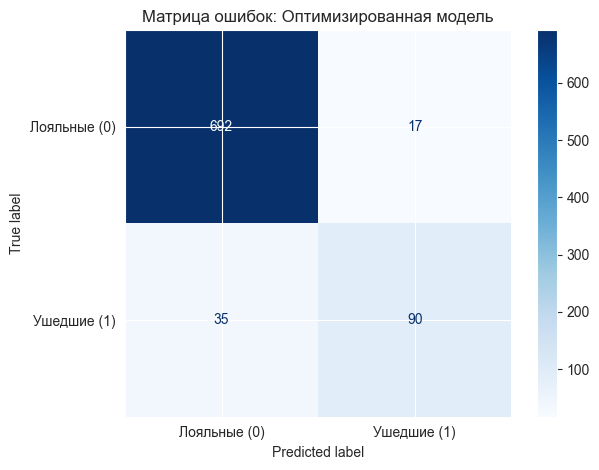

In [47]:
cm_new = confusion_matrix(y_test, y_pred_new)
disp_new = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=['Лояльные (0)', 'Ушедшие (1)'])
disp_new.plot(cmap='Blues', values_format='d')
plt.title("Матрица ошибок: Оптимизированная модель")
plt.tight_layout()
plt.savefig('confusion_matrix_optimized.png')
plt.show()

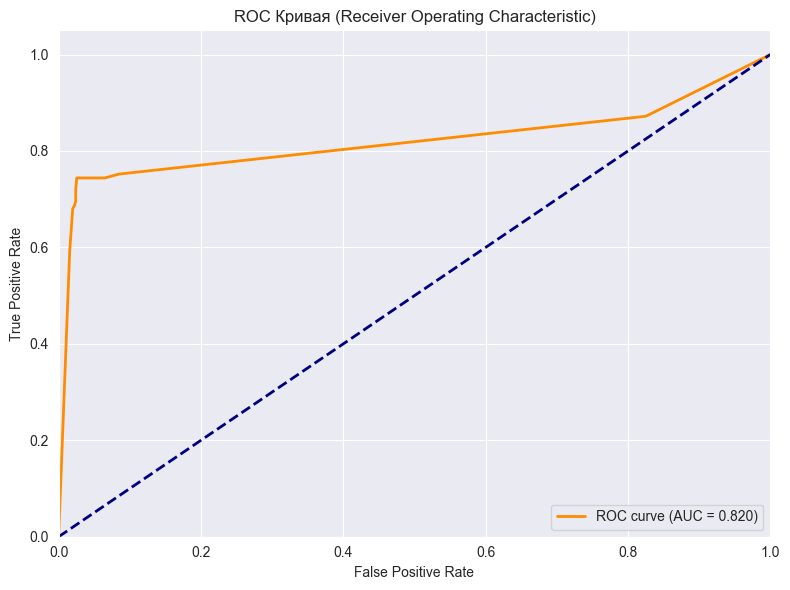

AUC-ROC: 0.820


In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_new)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Кривая (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()
print(f"AUC-ROC: {roc_auc:.3f}")

## Важность признаков (Feature Importance)

Топ-10 самых важных признаков:
1. total day minutes (0.2753)
2. international plan_yes (0.1842)
3. customer service calls (0.1386)
4. total eve charge (0.0688)
5. voice mail plan_yes (0.0512)
6. total intl minutes (0.0473)
7. total intl calls (0.0410)
8. total eve minutes (0.0171)
9. total night minutes (0.0166)
10. phone number_410-6791 (0.0146)


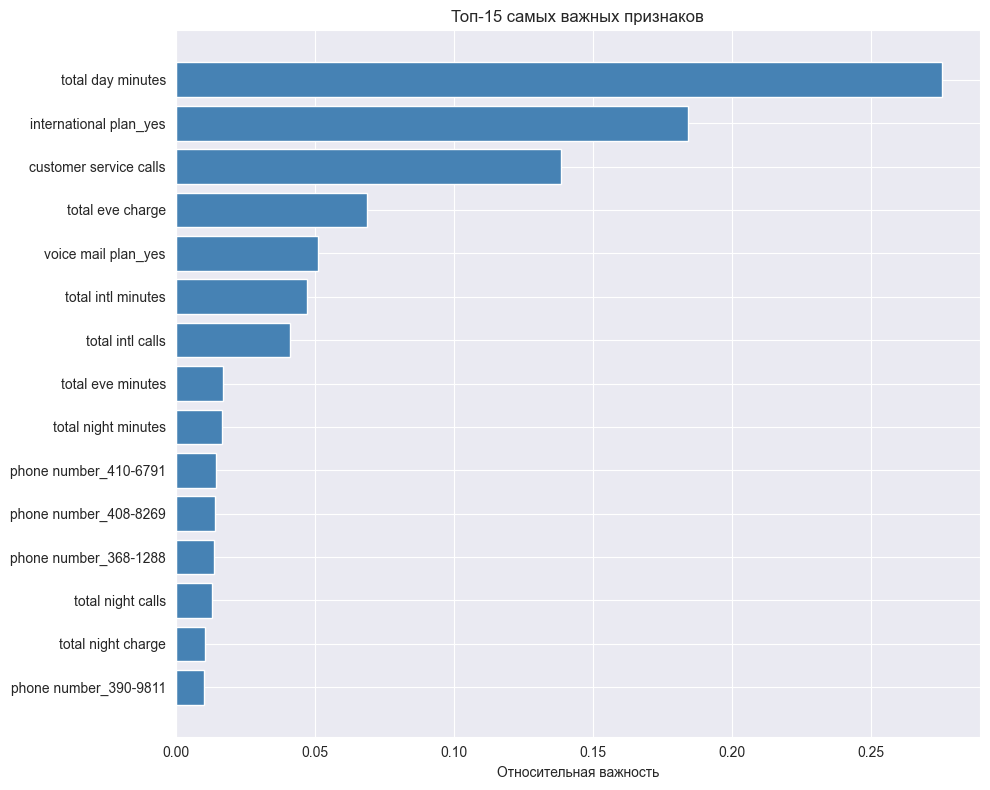

In [49]:
fitted_preprocessor = best_model.named_steps['preprocessor']

num_feat_names = numeric_features.tolist()

ohe = fitted_preprocessor.named_transformers_['cat']
cat_feat_names = ohe.get_feature_names_out(categorical_features).tolist()

all_feature_names = num_feat_names + cat_feat_names

classifier = best_model.named_steps['classifier']
importances = classifier.feature_importances_

indices = np.argsort(importances)[::-1]

print("Топ-10 самых важных признаков:")
for i in range(min(10, len(indices))):
    print(f"{i+1}. {all_feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

top_n = min(15, len(indices))
plt.figure(figsize=(10, 8))
plt.title("Топ-15 самых важных признаков")
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue', align='center')
plt.yticks(range(top_n), [all_feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel("Относительная важность")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

## Итоговое сравнение метрик

In [50]:
import warnings
warnings.filterwarnings('ignore')

data = [
    ['Accuracy (Точность)', f"{old_acc:.4f}", f"{new_acc:.4f}"],
    ['Precision', f"{old_prec:.4f}", f"{new_prec:.4f}"],
    ['Recall (Ушедшие)', f"{old_rec:.4f}", f"{new_rec:.4f}"],
    ['F1-Score', f"{old_f1:.4f}", f"{new_f1:.4f}"],
    ['ROC-AUC', '-', f"{roc_auc:.4f}"]
]
comp_df = pd.DataFrame(data, columns=['Метрика', 'Старая модель', 'Новая (Оптимизированная)'])
print(comp_df.to_string(index=False))
print("\nЦель: Повысить способность модели находить уходящих клиентов (Recall) при сохранении приемлемого уровня общего качества.")

            Метрика Старая модель Новая (Оптимизированная)
Accuracy (Точность)        0.9508                   0.9376
          Precision        0.8962                   0.8411
   Recall (Ушедшие)        0.7600                   0.7200
           F1-Score        0.8225                   0.7759
            ROC-AUC             -                   0.8203

Цель: Повысить способность модели находить уходящих клиентов (Recall) при сохранении приемлемого уровня общего качества.
